## IMPORT FILES

In [2]:
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tokenizers import Tokenizer

from dataSet import create_dataloader
from gptModel import (
    GPTModel,
    TINYSTORIES_CONFIG_29M,
    count_parameters,
    generate,
    text_to_token_ids,
    token_ids_to_text,
)

from processData import tokenize_split
from train_model import (
    create_optimizer,
    create_warmup_cosine_scheduler,
    evaluate_model,
    train_model,
)

print("PyTorch: ", torch.__version__)

PyTorch:  2.12.0+cu126


## REPRODUCIBILITY, HARDWARE AND RUN MODE

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# CHECK FOR QUICK RUN
QUICK_RUN = True
RESUME_FROM_LATEST = False

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RUN_NAME = "quick_1m" if QUICK_RUN else "tinystories_25m"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / RUN_NAME

for directory in (DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TOKENIZER_PATH = PROJECT_ROOT / "tinystories_tokenizer.json"

MODEL_CONFIG = dict(TINYSTORIES_CONFIG_29M)
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
NUM_WORKERS = 0

if QUICK_RUN:
    TRAIN_TOKEN_BUDGET = 1_000_000
    VALIDATION_TOKEN_BUDGET = 250_000
    EVAL_FREQUENCY = 25
    EVAL_BATCHES = 50
    CHECKPOINT_FREQUENCY = 100
else:
    TRAIN_TOKEN_BUDGET = 25_000_000
    VALIDATION_TOKEN_BUDGET = 1_000_000
    EVAL_FREQUENCY = 100
    EVAL_BATCHES = 100
    CHECKPOINT_FREQUENCY = 1_000

TRAIN_TOKEN_FILE = DATA_DIR / f"tinystories_train_{TRAIN_TOKEN_BUDGET}.bin"
VALIDATION_TOKEN_FILE = DATA_DIR / f"tinystories_validation_{VALIDATION_TOKEN_BUDGET}.bin"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
    )
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    print("WARNING: CUDA is unavailable. Use CPU only for a tiny smoke test.")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.00 GB


## LOAD AND VERIFY THE TOKENIZER

In [9]:
tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
vocab_size = tokenizer.get_vocab_size()
eos_id = tokenizer.token_to_id("<|endoftext|>")
unk_id = tokenizer.token_to_id("<|unk|>")

assert vocab_size == MODEL_CONFIG["vocab_size"], (
    f"Tokenizer has {vocab_size} tokens, but model config expects "
    f"{MODEL_CONFIG['vocab_size']}."
)
assert eos_id is not None
assert unk_id is not None
assert vocab_size == MODEL_CONFIG["vocab_size"]

sample_text = "Once upon a time, a little dragon found a red ball."
encoding = tokenizer.encode(sample_text)

assert max(encoding.ids) < vocab_size
assert min(encoding.ids) >= 0
assert tokenizer.decode(encoding.ids) == sample_text

print("Vocabulary size:", vocab_size)
print("UNK ID:", unk_id, "EOS ID:", eos_id)
print("Token IDs:", encoding.ids)
print("Tokens:", encoding.tokens)
print("Decoded:", tokenizer.decode(encoding.ids))

test_texts = [
    "Hello!",
    "Tom said, \"Let's go!\"",
    "The cat\nran outside.",
    "Lily had 3 red apples.",
    "Once upon a time, there was a tiny blue bird.",
]

for text in test_texts:
    encoded = tokenizer.encode(text)

    print("=" * 60)
    print("Original:", repr(text))
    print("IDs:", encoded.ids)
    print("Tokens:", encoded.tokens)
    print("Decoded:", repr(tokenizer.decode(encoded.ids)))
    print("Contains UNK:", unk_id in encoded.ids)

    assert all(0 <= token_id < vocab_size for token_id in encoded.ids)
    assert tokenizer.decode(encoded.ids) == text

Vocabulary size: 8000
UNK ID: 0 EOS ID: 1
Token IDs: [433, 448, 260, 397, 13, 260, 399, 1768, 598, 260, 928, 671, 15]
Tokens: ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġa', 'Ġlittle', 'Ġdragon', 'Ġfound', 'Ġa', 'Ġred', 'Ġball', '.']
Decoded: Once upon a time, a little dragon found a red ball.
Original: 'Hello!'
IDs: [1415, 2]
Tokens: ['Hello', '!']
Decoded: 'Hello!'
Contains UNK: False
Original: 'Tom said, "Let\'s go!"'
IDs: [739, 329, 13, 333, 953, 372, 438, 426]
Tokens: ['Tom', 'Ġsaid', ',', 'Ġ"', 'Let', "'s", 'Ġgo', '!"']
Decoded: 'Tom said, "Let\'s go!"'
Contains UNK: False
Original: 'The cat\nran outside.'
IDs: [375, 697, 200, 83, 301, 682, 15]
Tokens: ['The', 'Ġcat', 'Ċ', 'r', 'an', 'Ġoutside', '.']
Decoded: 'The cat\nran outside.'
Contains UNK: False
Original: 'Lily had 3 red apples.'
IDs: [343, 362, 2023, 928, 2188, 15]
Tokens: ['Lily', 'Ġhad', 'Ġ3', 'Ġred', 'Ġapples', '.']
Decoded: 'Lily had 3 red apples.'
Contains UNK: False
Original: 'Once upon a time, there was a tiny blue bir

## PREPARE BINARY TOKEN FILES:
The preprcessing function streams TinyStories, inserts EOS between stories, and stores IDs as uint16. Writes to a temporary file first, so an interrupted run does not look like a valid complete dataset.

In [6]:
def ensure_token_file(path, expected_tokens, split, shuffle_buffer_size):
    existing_tokens = (
        path.stat().st_size // np.dtype(np.uint16).itemsize
        if path.exists()
        else 0
    )

    if existing_tokens == expected_tokens:
        print(f"Ready: {path} ({existing_tokens:,} tokens)")
        return

    if path.exists():
        print(
            f"Rebuilding {path}: found {existing_tokens:,} tokens, "
            f"expected {expected_tokens:,}."
        )

    tokenize_split(
        split=split,
        output_file=path,
        tokenizer_file=TOKENIZER_PATH,
        max_tokens=expected_tokens,
        shuffle_buffer_size=shuffle_buffer_size,
        seed=SEED,
        overwrite=True,
    )


ensure_token_file(
    TRAIN_TOKEN_FILE,
    TRAIN_TOKEN_BUDGET,
    split="train",
    shuffle_buffer_size=10_000,
)
ensure_token_file(
    VALIDATION_TOKEN_FILE,
    VALIDATION_TOKEN_BUDGET,
    split="validation",
    shuffle_buffer_size=0,
)

Ready: C:\Users\owner\Desktop\Transformer\data\tinystories_train_1000000.bin (1,000,000 tokens)


Tokenizing validation:   0%|          | 0.00/250k [00:00<?, ?tok/s]

Wrote 250,000 tokens to C:\Users\owner\Desktop\Transformer\data\tinystories_validation_250000.bin


CREATE DATA LOADERS AND CALCULATE THE TRAINING BUDGET

In [7]:
train_loader = create_dataloader(
    token_file=TRAIN_TOKEN_FILE,
    context_length=MODEL_CONFIG["context_length"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    drop_last=True,
    seed=SEED,
)

validation_loader = create_dataloader(
    token_file=VALIDATION_TOKEN_FILE,
    context_length=MODEL_CONFIG["context_length"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    drop_last=False,
    seed=SEED,
)

effective_tokens_per_update = (
    BATCH_SIZE
    * MODEL_CONFIG["context_length"]
    * GRADIENT_ACCUMULATION_STEPS
)

# One pass over the selected training token file.
MAX_OPTIMIZER_STEPS = max(
    1,
    len(train_loader) // GRADIENT_ACCUMULATION_STEPS,
)
WARMUP_STEPS = max(10, int(0.03 * MAX_OPTIMIZER_STEPS))

print("Training sequences:", len(train_loader.dataset))
print("Validation sequences:", len(validation_loader.dataset))
print("Training micro-batches:", len(train_loader))
print("Effective tokens/update:", f"{effective_tokens_per_update:,}")
print("Optimizer steps:", f"{MAX_OPTIMIZER_STEPS:,}")
print("Warmup steps:", WARMUP_STEPS)
print(
    "Approximate optimized tokens:",
    f"{MAX_OPTIMIZER_STEPS * effective_tokens_per_update:,}",
)

Training sequences: 3906
Validation sequences: 976
Training micro-batches: 1953
Effective tokens/update: 8,192
Optimizer steps: 122
Warmup steps: 10
Approximate optimized tokens: 999,424


## INSPECTION AND VISUALIZATION OF DATA

In [10]:
input_batch, target_batch = next(iter(train_loader))

print("Input shape:", tuple(input_batch.shape))
print("Target shape:", tuple(target_batch.shape))
print("Dtype:", input_batch.dtype)
print("Minimum/maximum token ID:", input_batch.min().item(), input_batch.max().item())
print("Shift is correct:", torch.equal(input_batch[0, 1:], target_batch[0, :-1]))

print("\nDecoded input window:\n")
print(tokenizer.decode(input_batch[0].tolist(), skip_special_tokens=False))

print("\nFirst 30 input IDs:\n", input_batch[0, :30].tolist())
print("First 30 target IDs:\n", target_batch[0, :30].tolist())

Input shape: (2, 256)
Target shape: (2, 256)
Dtype: torch.int64
Minimum/maximum token ID: 1 7502
Shift is correct: True

Decoded input window:

 out, his cough was gone! Stanley was healed!

Stanley was so happy that he quickly ran to tell his friend the good news. His friend smiled and said, "That's one powerful freezer!" Finally, Stanley was free from his cough and could enjoy life again.<|endoftext|>Once upon a time, there was a bee who loved honey. He flew around looking for flowers and collecting the sweet honey. Everywhere he went, people told him how amazing he was.

One day, he saw a giant tree with lots of honey. He was so excited! He flew all around it, gathering as much as he could. But then, a huge gust of wind came and blew him away. He tried to stand up, but the wind was too strong.

Luckily, a friendly bear came to help! He took the bee back to the tree and helped him to stand up. Together they filled the bee's jar with honey. The bee was so happy and thanked the bear ma

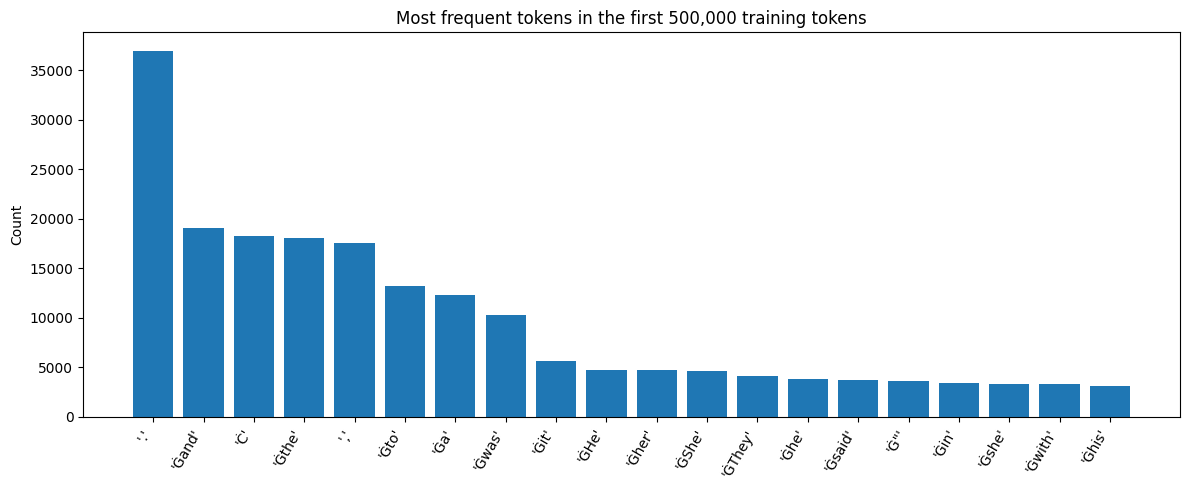

In [11]:
# Plot the most frequent tokens in a sample of the binary training stream.
train_tokens = np.memmap(TRAIN_TOKEN_FILE, dtype=np.uint16, mode="r")
sample_count = min(500_000, len(train_tokens))
sampled_ids = np.asarray(train_tokens[:sample_count], dtype=np.int64)
frequencies = np.bincount(sampled_ids, minlength=vocab_size)
top_ids = np.argsort(frequencies)[-20:][::-1]
labels = [repr(tokenizer.id_to_token(int(token_id))) for token_id in top_ids]

plt.figure(figsize=(12, 5))
plt.bar(labels, frequencies[top_ids])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Count")
plt.title(f"Most frequent tokens in the first {sample_count:,} training tokens")
plt.tight_layout()
plt.show()

## BUILD THE MODEL AND VERIFY ITS ARCHITECTURE

In [12]:
model = GPTModel(MODEL_CONFIG).to(device)
parameter_count = count_parameters(model)

print(model)
print(f"\nParameters: {parameter_count:,} ({parameter_count / 1e6:.2f}M)")
print(
    "Embedding weights tied:",
    model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr(),
)

assert parameter_count == 29_434_880
assert model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr()

GPTModel(
  (tok_emb): Embedding(8000, 512)
  (pos_emb): Embedding(256, 512)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=512, out_features=512, bias=False)
        (W_key): Linear(in_features=512, out_features=512, bias=False)
        (W_value): Linear(in_features=512, out_features=512, bias=False)
        (out_proj): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='tanh')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop_shortcut): Dropout(p=

## MANDATORY SMOKE TEST BEFORE THE LONG RUN
This performs a real forward and backward pass using the intended batch size. It catches shape errors, invalid token IDs, and most VRAM problems before the multi-hour run. The model is recreated afterward so the actual run starts from clean initialization

In [13]:
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

model.train()
smoke_inputs = input_batch.to(device, non_blocking=True)
smoke_targets = target_batch.to(device, non_blocking=True)

if device.type == "cuda":
    autocast_context = torch.amp.autocast("cuda", dtype=torch.float16)
else:
    from contextlib import nullcontext
    autocast_context = nullcontext()

with autocast_context:
    smoke_logits = model(smoke_inputs)
    smoke_loss = F.cross_entropy(
        smoke_logits.flatten(0, 1),
        smoke_targets.flatten(),
    )

smoke_loss.backward()
print("Logit shape:", tuple(smoke_logits.shape))
print("Smoke-test loss:", smoke_loss.item())
print("Finite loss:", math.isfinite(smoke_loss.item()))

if device.type == "cuda":
    print(
        "Peak allocated VRAM:",
        f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB",
    )

assert smoke_logits.shape == (
    BATCH_SIZE,
    MODEL_CONFIG["context_length"],
    MODEL_CONFIG["vocab_size"],
)
assert math.isfinite(smoke_loss.item())

del model, smoke_logits, smoke_loss
if device.type == "cuda":
    torch.cuda.empty_cache()

Logit shape: (2, 256, 8000)
Smoke-test loss: 9.074447631835938
Finite loss: True
Peak allocated VRAM: 0.30 GB


## RECREATE A CLEARN MODEL, OPTIMIZER, AND LEARNING-RATE SCHEDULER

In [14]:
# Re-seed so the clean model initialization is reproducible.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = GPTModel(MODEL_CONFIG).to(device)
optimizer = create_optimizer(
    model,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)
scheduler = create_warmup_cosine_scheduler(
    optimizer,
    warmup_steps=WARMUP_STEPS,
    total_steps=MAX_OPTIMIZER_STEPS,
    min_lr_ratio=0.1,
)

resume_path = CHECKPOINT_DIR / "latest.pt" if RESUME_FROM_LATEST else None
if resume_path is not None and not resume_path.exists():
    raise FileNotFoundError(resume_path)

print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("Resume checkpoint:", resume_path)

Initial learning rate: 2.9999999999999997e-05
Resume checkpoint: None


## OPTIONAL BASELINE GENERATION BEFORE TRAINING

In [15]:
prompt = "Once upon a time, there was a little dragon"
prompt_ids = text_to_token_ids(prompt, tokenizer).to(device)

baseline_ids = generate(
    model=model,
    idx=prompt_ids,
    max_new_tokens=80,
    context_size=MODEL_CONFIG["context_length"],
    temperature=0.8,
    top_k=40,
    eos_id=eos_id,
)

baseline_text = token_ids_to_text(
    baseline_ids,
    tokenizer,
    skip_special_tokens=True,
)
print(baseline_text)

Once upon a time, there was a little dragon screwdriver slimy fair screwdriver driveway sweets comfortable peacefulasm frustr objects wonders collecting Davey computer flown built Davey Tw spike folder Granny cute sandwiches squeaked Frank supply serve Tw widavy backed stage wasting folder flown slippery earlyMiss Tim potato roaring giggles bushes feeling job bicy costumasm thiefYeœYouâ Frank snail fair shadeMiss offer bright travelledord flat herRoseebookitingffee Bee opened see looks eraser refle�- bushes musician her screwdriver slippery


## TRAIN THE MODEL

For the first execution, keep `QUICK_RUN = True`. Only start the 25M-token run after the quick run finishes, creates checkpoints, produces finite losses, and generates a plot.

In [16]:
training_start = time.perf_counter()

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    optimizer=optimizer,
    device=device,
    max_optimizer_steps=MAX_OPTIMIZER_STEPS,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    eval_frequency=EVAL_FREQUENCY,
    checkpoint_frequency=CHECKPOINT_FREQUENCY,
    eval_batches=EVAL_BATCHES,
    scheduler=scheduler,
    checkpoint_dir=CHECKPOINT_DIR,
    resume_from=resume_path,
    keep_step_checkpoints=False,
)

training_hours = (time.perf_counter() - training_start) / 3600
print(f"Training call completed in {training_hours:.2f} hours")

Training:   0%|          | 0/122 [00:00<?, ?step/s]

Step 25 | tokens 204,800 | train 7.0754 | val 5.8026 | lr 2.88e-04
Step 50 | tokens 409,600 | train 5.6119 | val 5.1420 | lr 2.24e-04
Step 75 | tokens 614,400 | train 5.0673 | val 4.6290 | lr 1.31e-04
Step 100 | tokens 819,200 | train 4.7717 | val 4.4405 | lr 5.49e-05
Step 122 | tokens 999,424 | train 4.6349 | val 4.3713 | lr 3.00e-05
Training call completed in 0.02 hours


## SAVE AND PLOT THE METRICS

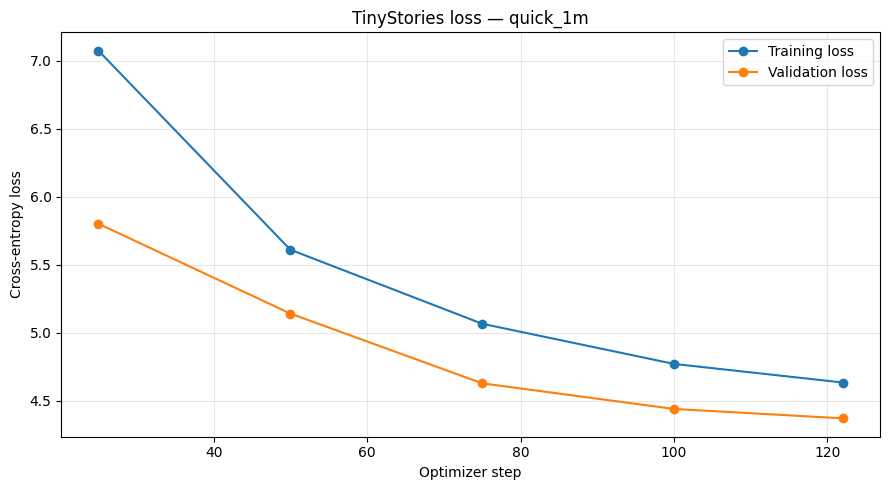

History: C:\Users\owner\Desktop\Transformer\outputs\quick_1m_training_history.json
Plot: C:\Users\owner\Desktop\Transformer\outputs\quick_1m_loss_curve.png
Best validation loss: 4.371344256401062


In [17]:
history_path = OUTPUT_DIR / f"{RUN_NAME}_training_history.json"
with history_path.open("w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

steps = history["optimizer_step"]

plt.figure(figsize=(9, 5))
plt.plot(steps, history["train_loss"], marker="o", label="Training loss")
plt.plot(steps, history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title(f"TinyStories loss — {RUN_NAME}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = OUTPUT_DIR / f"{RUN_NAME}_loss_curve.png"
plt.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("History:", history_path)
print("Plot:", loss_plot_path)
print("Best validation loss:", min(history["val_loss"]))

## LOAD THE BEST CHECKPOINT AND GENERATE FINAL SAMPLES

In [18]:
best_checkpoint_path = CHECKPOINT_DIR / "best.pt"
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(best_checkpoint["model"])
model.eval()

prompts = [
    "Once upon a time, there was a little dragon",
    "Lily was afraid of the dark, but one night",
    "Tom found a strange box under his bed",
]

generated_samples = {}
for prompt in prompts:
    prompt_ids = text_to_token_ids(prompt, tokenizer).to(device)
    output_ids = generate(
        model=model,
        idx=prompt_ids,
        max_new_tokens=180,
        context_size=MODEL_CONFIG["context_length"],
        temperature=0.8,
        top_k=40,
        eos_id=eos_id,
    )
    generated_text = token_ids_to_text(
        output_ids,
        tokenizer,
        skip_special_tokens=True,
    )
    generated_samples[prompt] = generated_text
    print("=" * 90)
    print(generated_text)

samples_path = OUTPUT_DIR / f"{RUN_NAME}_generated_samples.json"
with samples_path.open("w", encoding="utf-8") as file:
    json.dump(generated_samples, file, indent=2, ensure_ascii=False)

print("\nSaved samples to:", samples_path)

Once upon a time, there was a little dragon. She wanted to see a time, he was a a good was a little girl and went.



He was happy of the park for a little girl named Timmy was very happy and it. One day, there was so happy. He was was, the world and it was so happy.


"I made a big girl had to help a little girl. The garden. One day, â he had a time, "I'm very happy with the little she was so happy and Ben went to play with his old and started to play. It was very very brave back. The little girl named she was a time, "I'm that she felt happy.
Lily was afraid of the dark, but one night.



The girl went to his friends.
" I said, "One day, "You's not happy. They had a little girl was so happy.




The boy was so happy. She had very happy. He didn't know her mom. He loved to the door and looked out. She was so happy to keep her to play with her mom and the special and he wanted to be go to try to eat the sun.
Tom found a strange box under his bed with she was a big girl!

They time, it,

## SAVE A COMPACT MODEL ONLY ARTIFACT

In [19]:
model_artifact_path = OUTPUT_DIR / f"{RUN_NAME}_best_model.pt"
torch.save(
    {
        "model": model.state_dict(),
        "config": MODEL_CONFIG,
        "tokenizer_file": TOKENIZER_PATH.name,
        "optimizer_step": best_checkpoint["optimizer_step"],
        "tokens_seen": best_checkpoint["tokens_seen"],
        "best_val_loss": best_checkpoint["best_val_loss"],
    },
    model_artifact_path,
)

print("Model artifact:", model_artifact_path)
print(
    "Artifact size:",
    f"{model_artifact_path.stat().st_size / 1024**2:.1f} MB",
)

Model artifact: C:\Users\owner\Desktop\Transformer\outputs\quick_1m_best_model.pt
Artifact size: 112.3 MB
